In [2]:
from datetime import datetime
import pandas as pd
import yfinance as yf
import requests
import zipfile
from io import BytesIO
import numpy as np
import json

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# A. Brent 가격이랑 관련된 것만 넣어서 baseline

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [20]:
# ============================
# 1. Windowing Function
# ============================

def create_windows(df_scaled, df_original, target_col="brent_ret_5d", seq_len=30):
    """
    df_scaled  : 입력 피처들 (scaling된 데이터)
    df_original: 원본 데이터 (close값 + 원본 return 포함)
    target_col : 예측할 컬럼 (return)
    """
    X, y, close_today = [], [], []

    scaled_vals = df_scaled.values
    cols = df_scaled.columns.tolist()

    # 가격 복원용 close는 원본 사용
    original_close = df_original["brent_close"].values
    original_target = df_original[target_col].values   # ★ 원본 return 가져오기

    for i in range(len(df_scaled) - seq_len - 1):

        # 입력 시퀀스 (scaled)
        X.append(scaled_vals[i:i+seq_len])

        # target은 scaled 사용하면 절대 안됨!
        y.append(original_target[i+seq_len])

        # price 복원용 원본 close
        close_today.append(original_close[i+seq_len])

    return np.array(X), np.array(y), np.array(close_today)


# ============================
# 2. Dataset + Dataloader
# ============================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ============================
# 3. Bi-GRU Model
# ============================

class BiGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)  # BiGRU -> 2 * hidden

    def forward(self, x):
        out, _ = self.gru(x)          # out: (batch, seq_len, hidden*2)
        last = out[:, -1, :]          # 마지막 시점
        return self.fc(last)


# ============================
# 4. Train Function
# ============================

def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                pred = model(X_val)
                loss = criterion(pred, y_val)
                val_loss += loss.item()

        print(f"[Epoch {epoch:02d}] train={train_loss:.5f}, val={val_loss:.5f}")


# ============================
# 5. Predict & Price Restoration
# ============================

def predict_and_restore_price(model, X, close_today):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        pred_ret = model(X_tensor).numpy().reshape(-1)

    # price 복원
    pred_price = close_today * (1 + pred_ret)
    return pred_ret, pred_price


# ============================
# 6. 시각화
# ============================


def plot_results(y_test, pred_ret, close_test, pred_price):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # --- Return 시각화 ---
    axes[0].plot(y_test, label="Actual Return", linewidth=2)
    axes[0].plot(pred_ret, label="Predicted Return", linewidth=2)
    axes[0].set_title("Brent 1D Return Prediction")
    axes[0].legend()
    axes[0].grid(True)

    # --- Price 시각화 ---
    axes[1].plot(close_test, label="Actual Close Price", linewidth=2)
    axes[1].plot(pred_price, label="Predicted Close Price", linewidth=2)
    axes[1].set_title("Brent Close Price (Restored from Return)")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # 방향성 정확도
    direction = np.mean(np.sign(y_true) == np.sign(y_pred))

    print("\n===== Evaluation =====")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE : {mae:.6f}")
    print(f"Direction Accuracy: {direction:.4f}")

    return rmse, mae, direction

# ============================
# 7. Full Pipeline
# ============================

def run_bigru_pipeline(df, seq_len=30, target_col="brent_ret_5d"):

    # return 컬럼 전체 제거 (leakage 방지)
    ret_cols = [c for c in df.columns if "ret_" in c and c != target_col]

    df_input = df.drop(columns=ret_cols + ["brent_close", "wti_close"], errors="ignore")


    # 2) 스케일링 (input only)
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_input),
        index=df.index,
        columns=df_input.columns
    )

    # 3) window 생성 (y는 원본 return, close_today도 원본)
    X, y, close_today = create_windows(
        df_scaled,
        df_original=df,
        target_col=target_col,
        seq_len=seq_len
    )

    # ----- split -----
    train_size = int(len(X) * 0.7)
    val_size   = int(len(X) * 0.15)

    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val     = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
    X_test, y_test   = X[train_size+val_size:], y[train_size+val_size:]
    close_test       = close_today[train_size+val_size:]

    # ----- dataloader -----
    train_ds = TimeSeriesDataset(X_train, y_train)
    val_ds   = TimeSeriesDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    # ----- model -----
    input_dim = X.shape[2]
    model = BiGRU(input_dim=input_dim, hidden_dim=64, num_layers=1)

    # ----- train -----
    train_model(model, train_loader, val_loader, epochs=40, lr=1e-3)

    # ----- test prediction -----
    pred_ret, pred_price = predict_and_restore_price(model, X_test, close_test)

    # ----- evaluation -----
    rmse, mae, direction = evaluate_predictions(y_test, pred_ret)

    # ----- plot -----
    plot_results(y_test, pred_ret, close_test, pred_price)

    return {
        "model": model,
        "metrics": {
            "rmse": rmse,
            "mae": mae,
            "direction_accuracy": direction
        },
        "prediction": {
            "y_test": y_test,
            "pred_ret": pred_ret,
            "pred_price": pred_price
        },
        "scaler": scaler
    }


In [34]:
def make_brent_wti_features(start="2013-09-01", end=None, target_horizon=1):
    import yfinance as yf
    import pandas as pd

    brent = yf.download("BZ=F", start=start, end=end, auto_adjust=False, progress=False)
    wti   = yf.download("CL=F", start=start, end=end, auto_adjust=False, progress=False)

    brent = brent.rename(columns=str.lower)
    wti   = wti.rename(columns=str.lower)

    df = pd.DataFrame(index=brent.index)
    df["brent_close"] = brent["close"]
    df["wti_close"]   = wti["close"].reindex(df.index)

    # Spread
    df["brent_wti_spread"] = df["brent_close"] - df["wti_close"]

    # Returns (미래 정보 포함 가능성 있음 → 뒤에서 필터링)
    df["brent_ret_1d"]  = df["brent_close"].pct_change(1)
    df["brent_ret_5d"]  = df["brent_close"].pct_change(5)
    df["brent_ret_20d"] = df["brent_close"].pct_change(20)

    df["wti_ret_1d"]  = df["wti_close"].pct_change(1)
    df["wti_ret_5d"]  = df["wti_close"].pct_change(5)
    df["wti_ret_20d"] = df["wti_close"].pct_change(20)

    # Moving averages
    df["brent_ma_5"]  = df["brent_close"].rolling(5).mean()
    df["brent_ma_20"] = df["brent_close"].rolling(20).mean()
    df["brent_ma_60"] = df["brent_close"].rolling(60).mean()

    df["wti_ma_5"]  = df["wti_close"].rolling(5).mean()
    df["wti_ma_20"] = df["wti_close"].rolling(20).mean()
    df["wti_ma_60"] = df["wti_close"].rolling(60).mean()

    # Volatility proxies
    df["brent_vol_5d"] = df["brent_close"].pct_change().rolling(5).std()
    df["wti_vol_5d"]   = df["wti_close"].pct_change().rolling(5).std()

    df["high_low_range"] = (brent["high"] - brent["low"]) / brent["close"]

    # ============================
    # 🔥 완전 자동 leakage 방지
    # ============================
    if target_horizon == 1:
        # 1D 예측은 안전 → 그대로 두기
        pass

    elif target_horizon == 5:
        # 5D 예측 → 어떤 5D/20D return feature도 남아 있으면 안 됨
        drop_cols = [
            c for c in df.columns
            if (
                ("ret_5d" in c or "ret_20d" in c)
                and c != "brent_ret_5d"  # 타겟만 남기기
            )
        ]
        df = df.drop(columns=drop_cols)

    elif target_horizon == 20:
        # 20D 예측 → 5d/20d return 전부 제거 (타겟 제외)
        drop_cols = [
            c for c in df.columns
            if ("ret_5d" in c or "ret_20d" in c)
            and c != "brent_ret_20d"
        ]
        df = df.drop(columns=drop_cols)

    return df.dropna()


features = make_brent_wti_features(target_horizon=5)
features = features[features.index >= "2014-01-01"]
print(features.tail())


            brent_close  wti_close  brent_wti_spread  brent_ret_1d  \
Date                                                                 
2025-11-13    63.009998  58.689999          4.320000      0.004784   
2025-11-14    64.389999  60.090000          4.299999      0.021901   
2025-11-17    64.199997  59.910000          4.289997     -0.002951   
2025-11-18    64.889999  60.740002          4.149998      0.010748   
2025-11-19    63.330002  59.790001          3.540001     -0.024041   

            brent_ret_5d  wti_ret_1d  brent_ma_5  brent_ma_20  brent_ma_60  \
Date                                                                         
2025-11-13     -0.005838    0.003419   63.714000      63.8975    65.674500   
2025-11-14      0.011944    0.023854   63.866000      64.0525    65.619833   
2025-11-17      0.002185   -0.002996   63.893999      64.2120    65.561000   
2025-11-18     -0.004144    0.013854   63.839999      64.3905    65.495833   
2025-11-19      0.009887   -0.015640   63

C:\Users\SKAX\AppData\Local\Temp\ipykernel_25512\573625205.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_1d"]  = df["wti_close"].pct_change(1)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_25512\573625205.py:24: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_5d"]  = df["wti_close"].pct_change(5)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_25512\573625205.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_metho

In [35]:
print(features.columns.tolist())


['brent_close', 'wti_close', 'brent_wti_spread', 'brent_ret_1d', 'brent_ret_5d', 'wti_ret_1d', 'brent_ma_5', 'brent_ma_20', 'brent_ma_60', 'wti_ma_5', 'wti_ma_20', 'wti_ma_60', 'brent_vol_5d', 'wti_vol_5d', 'high_low_range']


[Epoch 01] train=0.15941, val=0.02632
[Epoch 02] train=0.07443, val=0.02391
[Epoch 03] train=0.09570, val=0.01733
[Epoch 04] train=0.08928, val=0.01814
[Epoch 05] train=0.08132, val=0.02049
[Epoch 06] train=0.07304, val=0.02258
[Epoch 07] train=0.07671, val=0.02042
[Epoch 08] train=0.06598, val=0.01743
[Epoch 09] train=0.06881, val=0.01875
[Epoch 10] train=0.07018, val=0.02097
[Epoch 11] train=0.07018, val=0.01590
[Epoch 12] train=0.07285, val=0.02133
[Epoch 13] train=0.06302, val=0.01774
[Epoch 14] train=0.06761, val=0.01729
[Epoch 15] train=0.06744, val=0.01649
[Epoch 16] train=0.06608, val=0.01966
[Epoch 17] train=0.06609, val=0.03747
[Epoch 18] train=0.06976, val=0.01767
[Epoch 19] train=0.06485, val=0.01825
[Epoch 20] train=0.06508, val=0.01651
[Epoch 21] train=0.06419, val=0.01615
[Epoch 22] train=0.06000, val=0.01930
[Epoch 23] train=0.06076, val=0.02621
[Epoch 24] train=0.06196, val=0.01681
[Epoch 25] train=0.05905, val=0.02992
[Epoch 26] train=0.05897, val=0.03680
[Epoch 27] t

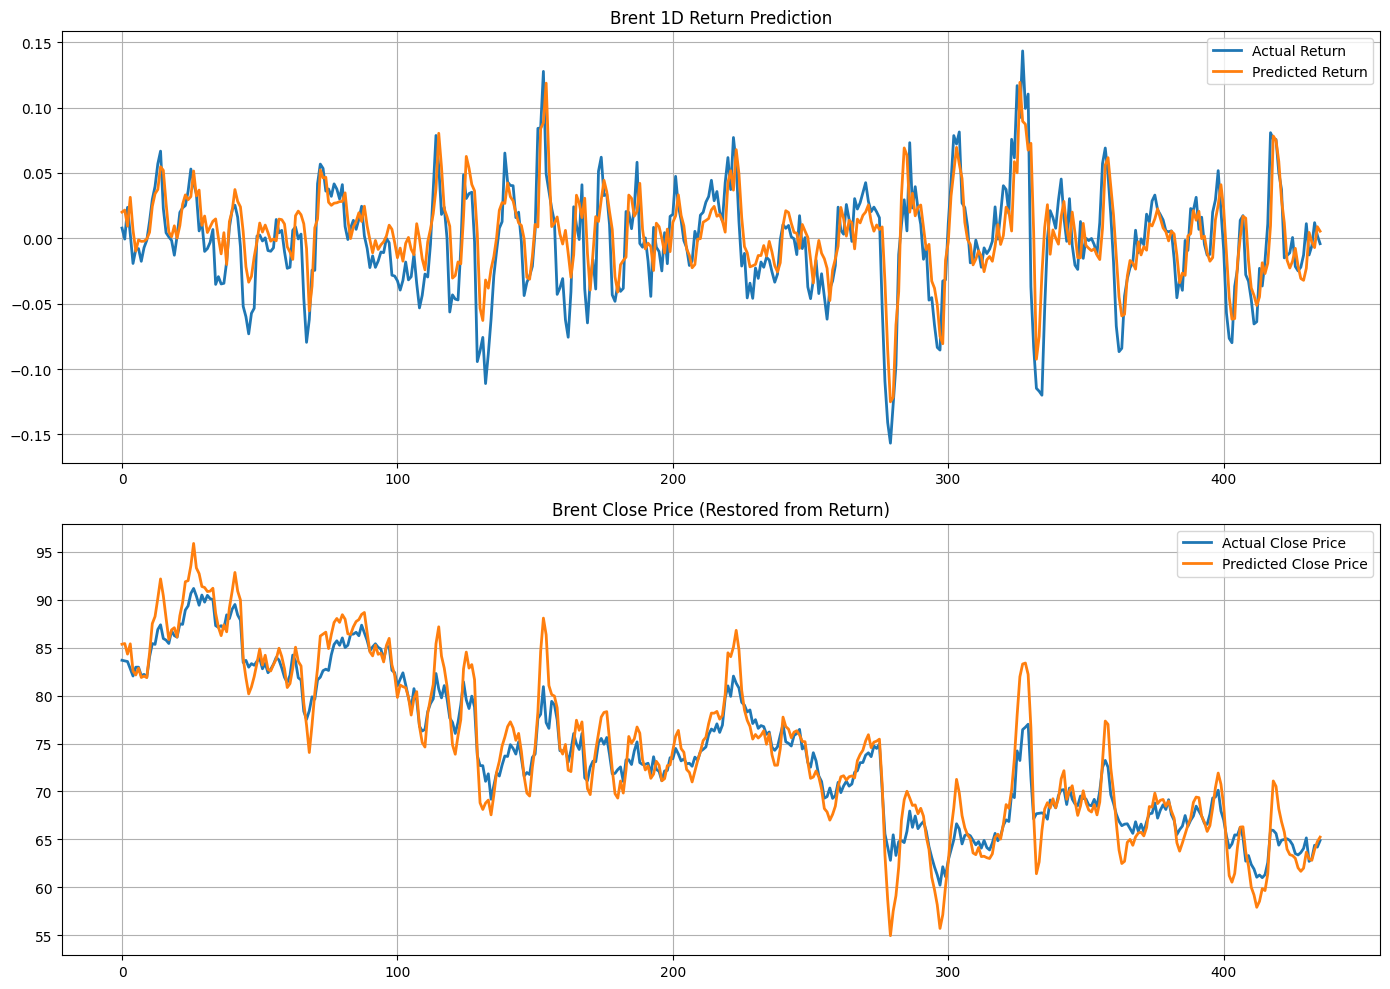

{'model': BiGRU(
   (gru): GRU(11, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.026815708423554085),
  'mae': 0.020136369963010412,
  'direction_accuracy': np.float64(0.7614678899082569)},
 'prediction': {'y_test': array([ 7.82851422e-03, -5.97531056e-04,  2.36461681e-02,  3.27158944e-03,
         -1.92468689e-02, -8.60422106e-03, -7.89289214e-03, -1.75942689e-02,
         -7.12565152e-03, -1.46273458e-03,  1.28977785e-02,  2.96528340e-02,
          3.97172811e-02,  5.69273854e-02,  6.66503809e-02,  2.28489610e-02,
          4.21447691e-03,  1.05465164e-03, -1.61122558e-03, -1.29319900e-02,
          1.62884694e-03,  1.98181931e-02,  2.32938998e-02,  2.50143881e-02,
          3.59420113e-02,  5.29678869e-02,  4.21810090e-02,  3.38595189e-02,
          5.62303205e-03,  1.26469491e-02, -1.00386503e-02, -7.89734820e-03,
         -3.09801713e-03,  6.70989137e-03, -3.52564359e-02, -2.93068567e-02,

In [36]:
df = features.copy()
result = run_bigru_pipeline(df)
result

# B. EIA 추가

In [37]:
API_KEY = "m9fePZTks6kdpVDleRYzWYJMdZOXubKwwTHYuiPJ"

# ------------------------------
# 1. fetch functions (원본 그대로)
# ------------------------------

def fetch_crude_stock():
    url = "https://api.eia.gov/v2/seriesid/PET.WCESTUS1.W"
    params = {"api_key": API_KEY}
    r = requests.get(url, params=params)
    r.raise_for_status()
    js = r.json()

    df = pd.DataFrame(js["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df["value"] = pd.to_numeric(df["value"])
    df = df.sort_values("period")
    df = df.rename(columns={"value": "crude_stock_level"})
    return df[["period", "crude_stock_level"]]


def fetch_gas_stock_total():
    url = "https://api.eia.gov/v2/seriesid/PET.WGTSTUS1.W"
    params = {"api_key": API_KEY}
    r = requests.get(url, params=params)
    r.raise_for_status()
    js = r.json()

    df = pd.DataFrame(js["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df["value"] = pd.to_numeric(df["value"])
    df = df.sort_values("period")
    df = df.rename(columns={"value": "gas_stock_level"})
    return df[["period", "gas_stock_level"]]


def fetch_dist_stock_total():
    url = "https://api.eia.gov/v2/seriesid/PET.WDISTUS1.W"  # ★ 수정 (증류유)
    params = {"api_key": API_KEY}
    r = requests.get(url, params=params)
    r.raise_for_status()
    js = r.json()

    df = pd.DataFrame(js["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df["value"] = pd.to_numeric(df["value"])
    df = df.sort_values("period")
    df = df.rename(columns={"value": "dist_stock_level"})
    return df[["period", "dist_stock_level"]]


# ------------------------------
# 2. Index 설정 도우미
# ------------------------------

def set_period_index(df, col):
    out = df.copy()
    out["period"] = pd.to_datetime(out["period"])
    out = out.set_index("period").sort_index()
    return out[[col]]


# ------------------------------
# 3. EIA Load + Derived Features 생성
# ------------------------------

def load_eia_with_features():
    # (1) fetch
    crude = fetch_crude_stock()
    gas = fetch_gas_stock_total()
    dist = fetch_dist_stock_total()

    # (2) indexing
    crude_i = set_period_index(crude, "crude_stock_level")
    gas_i   = set_period_index(gas, "gas_stock_level")
    dist_i  = set_period_index(dist, "dist_stock_level")

    # (3) merge
    stocks = pd.concat([crude_i, gas_i, dist_i], axis=1)

    # -------------------------
    # 파생변수 생성
    # -------------------------

    # (A) WoW 변화량
    stocks["crude_stock_wow_change"] = stocks["crude_stock_level"].diff()
    stocks["gas_stock_wow_change"]   = stocks["gas_stock_level"].diff()
    stocks["dist_stock_wow_change"]  = stocks["dist_stock_level"].diff()

    # (B) 5년 평균 (52주 x 5)
    win_5yr = 52 * 5

    stocks["crude_5yr_avg"] = stocks["crude_stock_level"].rolling(win_5yr).mean()
    stocks["gas_5yr_avg"]   = stocks["gas_stock_level"].rolling(win_5yr).mean()
    stocks["dist_5yr_avg"]  = stocks["dist_stock_level"].rolling(win_5yr).mean()

    # (C) 5년 평균 대비 편차
    stocks["crude_vs_5yr_avg"] = stocks["crude_stock_level"] - stocks["crude_5yr_avg"]
    stocks["gas_vs_5yr_avg"]   = stocks["gas_stock_level"] - stocks["gas_5yr_avg"]
    stocks["dist_vs_5yr_avg"]  = stocks["dist_stock_level"] - stocks["dist_5yr_avg"]

    # (D) Z-score (52주 표준편차)
    stocks["crude_zscore"] = (stocks["crude_vs_5yr_avg"] /
                              stocks["crude_stock_level"].rolling(52).std())

    stocks["gas_zscore"] = (stocks["gas_vs_5yr_avg"] /
                            stocks["gas_stock_level"].rolling(52).std())

    stocks["dist_zscore"] = (stocks["dist_vs_5yr_avg"] /
                             stocks["dist_stock_level"].rolling(52).std())

    return stocks


# ------------------------------
# 4. 가격 feature df에 merge하는 함수
# ------------------------------

def merge_eia_to_features(features_df):
    """
    features_df: Brent/WTI 기반 feature 만들던 df (daily)
    """

    # 1) 원본 EIA weekly
    eia = load_eia_with_features()

    # 2) weekly → daily
    # 발표일 값이 다음 발표일까지 유지되도록 확실하게 forward fill
    eia_daily = eia.resample("1D").ffill()

    # 3) price df index가 datetime인지 보정
    features_df = features_df.copy()
    features_df.index = pd.to_datetime(features_df.index)

    # 4) price timeline에 맞추기
    eia_daily = eia_daily.reindex(features_df.index).ffill()

    # 5) merge
    merged = pd.concat([features_df, eia_daily], axis=1)

    return merged

In [38]:
features = make_brent_wti_features()
features = features[features.index >= "2014-01-01"]

features_b = merge_eia_to_features(features)
features_b.head()

C:\Users\SKAX\AppData\Local\Temp\ipykernel_25512\573625205.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_1d"]  = df["wti_close"].pct_change(1)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_25512\573625205.py:24: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_5d"]  = df["wti_close"].pct_change(5)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_25512\573625205.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_metho

,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,wti_ret_1d,wti_ret_5d,wti_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,wti_ma_5,wti_ma_20,wti_ma_60,brent_vol_5d,wti_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_5yr_avg,gas_5yr_avg,dist_5yr_avg,crude_vs_5yr_avg,gas_vs_5yr_avg,dist_vs_5yr_avg,crude_zscore,gas_zscore,dist_zscore
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.032930,-0.030278,-0.038097,0.017267,110.790001,110.6705,109.391334,98.604001,97.9800,97.413000,0.011831,0.014810,0.033680,330695.0,220716.0,119147.0,-7007.0,844.0,5042.0,335195.292308,216338.500000,142926.357692,-4500.292308,4377.500000,-23779.357692,-0.350348,0.684699,-3.867273
2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.050879,-0.015507,-0.056153,-0.021658,109.772000,110.3840,109.356167,97.486000,97.8760,97.257167,0.010935,0.013672,0.017214,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366
2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0.046031,-0.005641,-0.068680,-0.038786,108.682001,110.1265,109.310667,96.108000,97.6875,97.083667,0.010182,0.009727,0.012836,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366
2014-01-07,107.349998,93.669998,13.680000,0.005809,-0.034709,-0.032709,0.002569,-0.056602,-0.038098,107.910001,109.9450,109.271834,94.984000,97.5020,96.927667,0.012422,0.012333,0.007452,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366
2014-01-08,107.150002,92.330002,14.820000,-0.001863,-0.032942,-0.039961,-0.014306,-0.061878,-0.054480,107.180000,109.7220,109.221667,93.766000,97.2360,96.741667,0.012569,0.012272,0.008493,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366


[Epoch 01] train=0.28524, val=0.04101
[Epoch 02] train=0.09129, val=0.02655
[Epoch 03] train=0.07758, val=0.03370
[Epoch 04] train=0.07921, val=0.04527
[Epoch 05] train=0.07614, val=0.01860
[Epoch 06] train=0.06899, val=0.03966
[Epoch 07] train=0.07461, val=0.02083
[Epoch 08] train=0.07153, val=0.02407
[Epoch 09] train=0.06921, val=0.01909
[Epoch 10] train=0.07264, val=0.02136
[Epoch 11] train=0.06569, val=0.02192
[Epoch 12] train=0.06779, val=0.01919
[Epoch 13] train=0.07100, val=0.02520
[Epoch 14] train=0.06635, val=0.01784
[Epoch 15] train=0.06153, val=0.01950
[Epoch 16] train=0.06114, val=0.01936
[Epoch 17] train=0.05754, val=0.02049
[Epoch 18] train=0.05534, val=0.01921
[Epoch 19] train=0.05575, val=0.02032
[Epoch 20] train=0.05634, val=0.02054
[Epoch 21] train=0.05894, val=0.01984
[Epoch 22] train=0.05691, val=0.01962
[Epoch 23] train=0.06011, val=0.01872
[Epoch 24] train=0.05506, val=0.02805
[Epoch 25] train=0.05809, val=0.02206
[Epoch 26] train=0.06363, val=0.01883
[Epoch 27] t

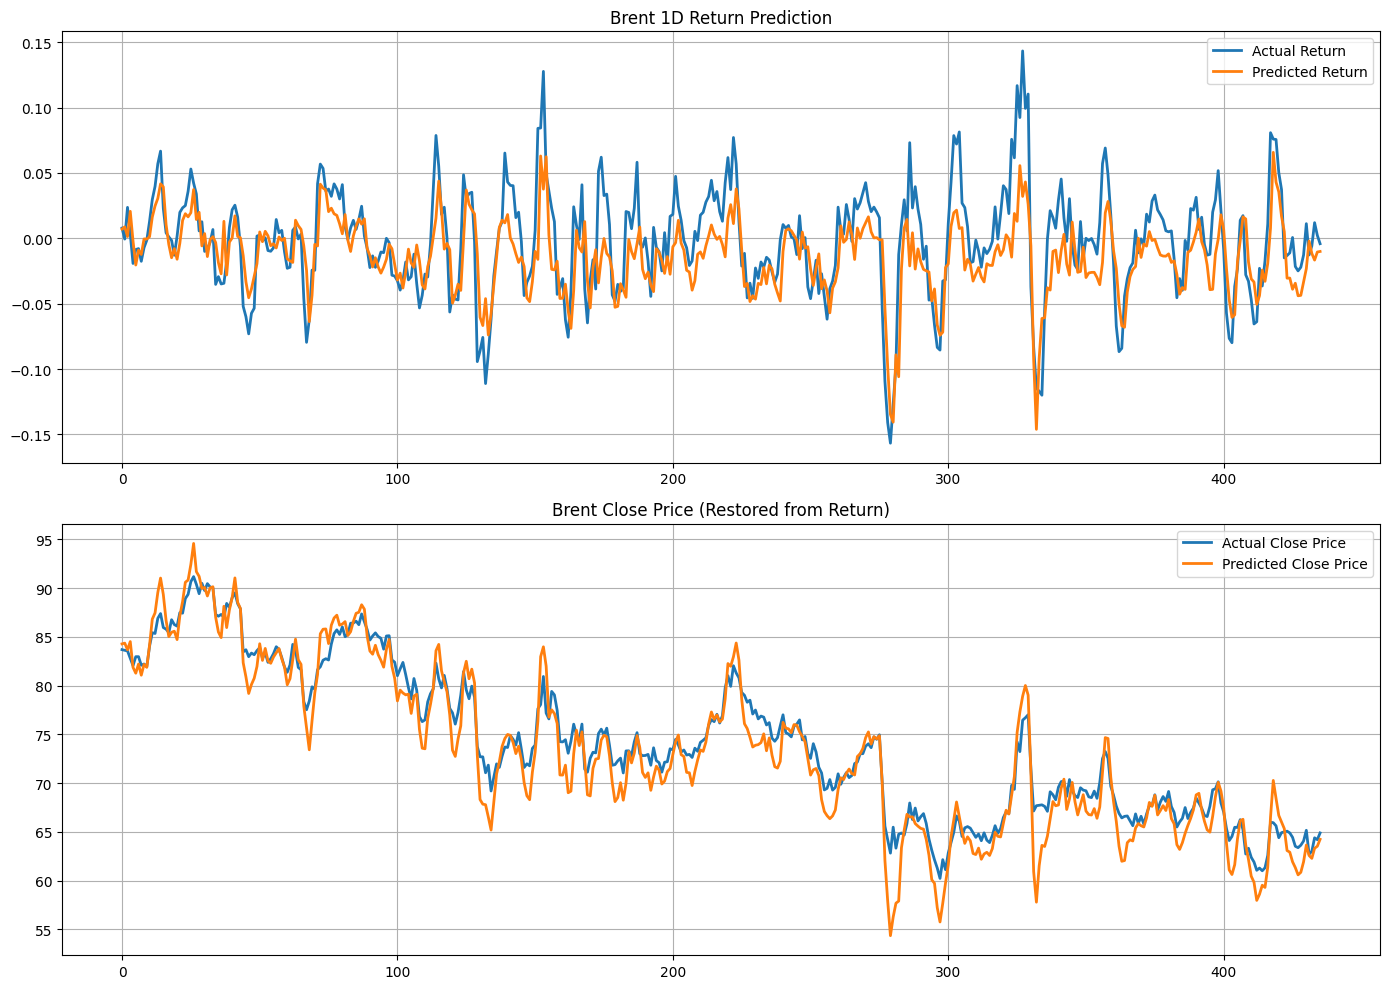

{'model': BiGRU(
   (gru): GRU(26, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.02957199059939337),
  'mae': 0.02241946079409879,
  'direction_accuracy': np.float64(0.7270642201834863)},
 'prediction': {'y_test': array([ 7.82851422e-03, -5.97531056e-04,  2.36461681e-02,  3.27158944e-03,
         -1.92468689e-02, -8.60422106e-03, -7.89289214e-03, -1.75942689e-02,
         -7.12565152e-03, -1.46273458e-03,  1.28977785e-02,  2.96528340e-02,
          3.97172811e-02,  5.69273854e-02,  6.66503809e-02,  2.28489610e-02,
          4.21447691e-03,  1.05465164e-03, -1.61122558e-03, -1.29319900e-02,
          1.62884694e-03,  1.98181931e-02,  2.32938998e-02,  2.50143881e-02,
          3.59420113e-02,  5.29678869e-02,  4.21810090e-02,  3.38595189e-02,
          5.62303205e-03,  1.26469491e-02, -1.00386503e-02, -7.89734820e-03,
         -3.09801713e-03,  6.70989137e-03, -3.52564359e-02, -2.93068567e-02,
 

In [39]:
df = features_b.copy()
result = run_bigru_pipeline(df)
result

# B-1 EIA 데이터에서 파생변수만 쓰기

In [40]:
cols_to_remove = [
    "crude_stock_level", "gas_stock_level", "dist_stock_level",
    "crude_imports", "crude_exports", "net_imports",
    "prod_weekly", "prod_4w_ma", "prod_wow_change",
    "import_4w_ma",
    "refinery_run_rate"
]
features_b_1 = features_b.drop(columns=[c for c in features_b.columns 
                                      if any(k in c for k in [
                                          "stock_", "imports", "export", 
                                          "prod_", "refinery"
                                      ])])


[Epoch 01] train=0.25426, val=0.04255
[Epoch 02] train=0.08307, val=0.02211
[Epoch 03] train=0.07445, val=0.02071
[Epoch 04] train=0.07033, val=0.02169
[Epoch 05] train=0.07087, val=0.02029
[Epoch 06] train=0.07111, val=0.01952
[Epoch 07] train=0.07802, val=0.02046
[Epoch 08] train=0.07535, val=0.02196
[Epoch 09] train=0.06552, val=0.02243
[Epoch 10] train=0.06928, val=0.02128
[Epoch 11] train=0.06375, val=0.01897
[Epoch 12] train=0.06345, val=0.02805
[Epoch 13] train=0.06158, val=0.02064
[Epoch 14] train=0.06484, val=0.02273
[Epoch 15] train=0.06335, val=0.02331
[Epoch 16] train=0.06682, val=0.02050
[Epoch 17] train=0.06786, val=0.02270
[Epoch 18] train=0.05948, val=0.02272
[Epoch 19] train=0.06143, val=0.01967
[Epoch 20] train=0.05642, val=0.02054
[Epoch 21] train=0.06065, val=0.02098
[Epoch 22] train=0.06054, val=0.02061
[Epoch 23] train=0.06066, val=0.02133
[Epoch 24] train=0.05916, val=0.01821
[Epoch 25] train=0.05770, val=0.02134
[Epoch 26] train=0.05788, val=0.01932
[Epoch 27] t

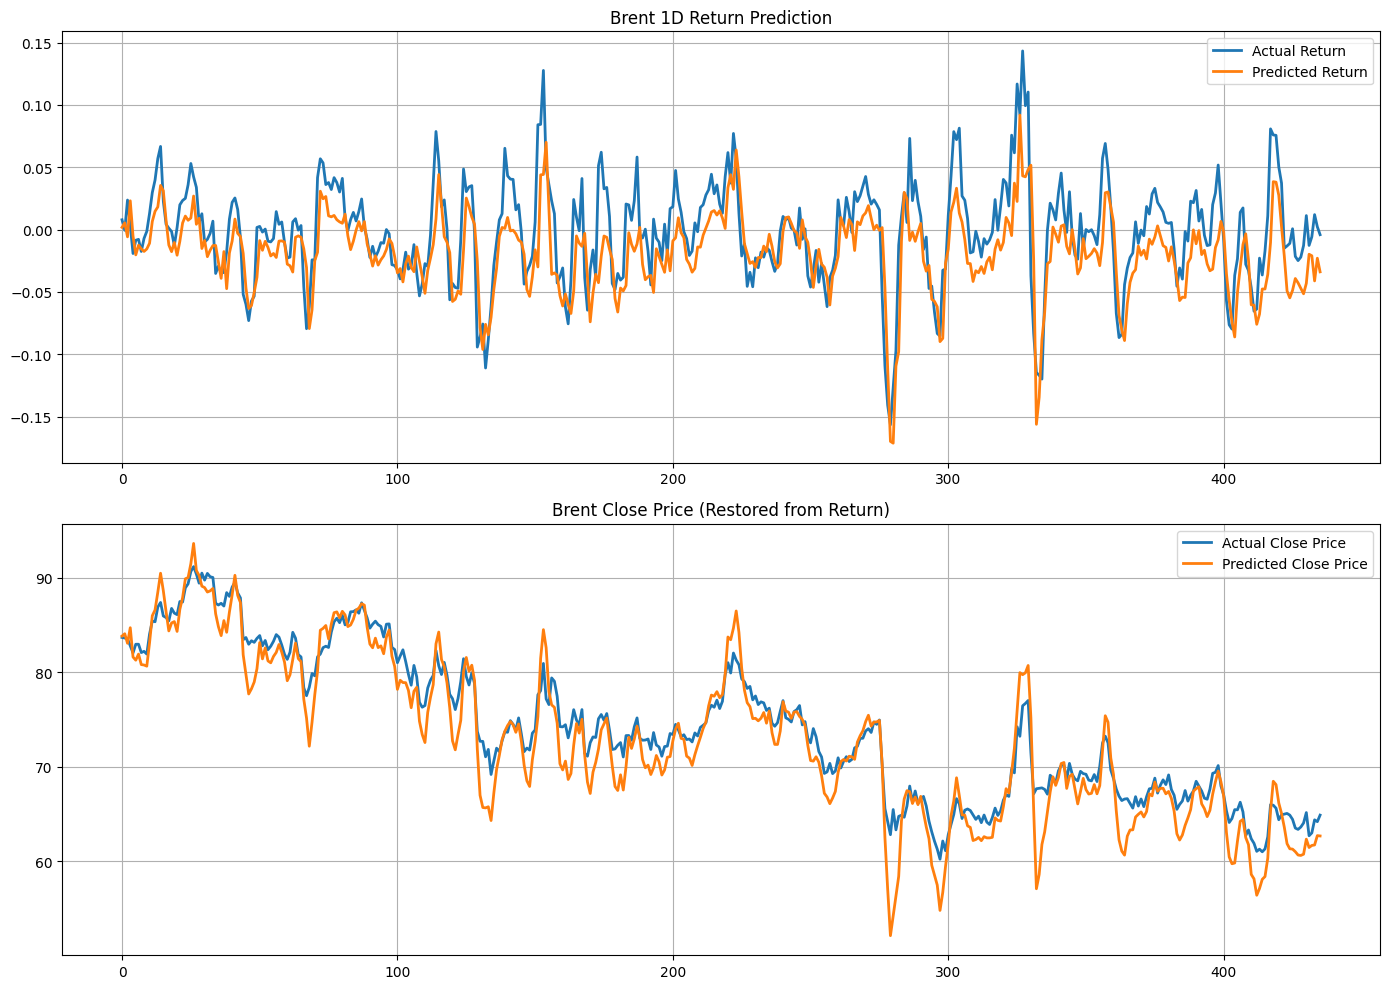

{'model': BiGRU(
   (gru): GRU(20, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.03063939075966924),
  'mae': 0.02389047060215244,
  'direction_accuracy': np.float64(0.7155963302752294)},
 'prediction': {'y_test': array([ 7.82851422e-03, -5.97531056e-04,  2.36461681e-02,  3.27158944e-03,
         -1.92468689e-02, -8.60422106e-03, -7.89289214e-03, -1.75942689e-02,
         -7.12565152e-03, -1.46273458e-03,  1.28977785e-02,  2.96528340e-02,
          3.97172811e-02,  5.69273854e-02,  6.66503809e-02,  2.28489610e-02,
          4.21447691e-03,  1.05465164e-03, -1.61122558e-03, -1.29319900e-02,
          1.62884694e-03,  1.98181931e-02,  2.32938998e-02,  2.50143881e-02,
          3.59420113e-02,  5.29678869e-02,  4.21810090e-02,  3.38595189e-02,
          5.62303205e-03,  1.26469491e-02, -1.00386503e-02, -7.89734820e-03,
         -3.09801713e-03,  6.70989137e-03, -3.52564359e-02, -2.93068567e-02,
 

In [41]:
df = features_b_1.copy()
result = run_bigru_pipeline(df)
result

# C. COT 추가

In [42]:
def fetch_cot_raw(start_year=2009, end_year=2025):
    base_url = "https://www.cftc.gov/files/dea/history/fut_disagg_txt_{}.zip"
    all_df = []

    for year in range(start_year, end_year + 1):
        url = base_url.format(year)

        try:
            res = requests.get(url)
            res.raise_for_status()

            with zipfile.ZipFile(BytesIO(res.content)) as z:
                for name in z.namelist():
                    if name.endswith(".txt"):
                        df = pd.read_csv(z.open(name), header=None)
                        df["year"] = year
                        all_df.append(df)

        except:
            pass  # 조용히 skip

    if len(all_df) == 0:
        raise RuntimeError("COT raw 다운로드 실패")

    df_all = pd.concat(all_df, ignore_index=True)
    return df_all

def extract_cot_features(df_all):
    """
    df_all: CFTC disagg futures raw merged
    반환: cot_daily (날짜 index)
    """

    # ----- 헤더 처리 -----
    if df_all.iloc[0, 0] == "Market_and_Exchange_Names":
        df_all.columns = df_all.iloc[0]
        df_all = df_all.drop(index=0).reset_index(drop=True)

    df_all.columns = [str(c).strip() for c in df_all.columns]
    df_all = df_all.rename(columns=lambda x: x.replace("-", "_").replace(" ", "_"))

    # 날짜 컬럼 자동 탐색
    date_col = next((c for c in df_all.columns if "report_date" in c.lower()), None)
    df_all["date"] = pd.to_datetime(df_all[date_col], errors="coerce")

    # 핵심 포지션 컬럼
    mm_long = "M_Money_Positions_Long_All"
    mm_short = "M_Money_Positions_Short_All"
    prod_short = "Prod_Merc_Positions_Short_All"
    oi_col = "Open_Interest_All"

    # 숫자 처리
    for col in [mm_long, mm_short, prod_short, oi_col]:
        if col in df_all.columns:
            df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

    # 시장명 소문자
    df_all["Market_and_Exchange_Names"] = (
        df_all["Market_and_Exchange_Names"].astype(str).str.lower()
    )

    # WTI만 필터링
    wti = df_all[
        df_all["Market_and_Exchange_Names"].str.contains("crude oil, light sweet", na=False)
    ].copy()

    # ----- 피처 생성 -----
    wti = (
        wti.sort_values("date")
           .groupby("date", as_index=False)
           .last()
    )

    wti["wti_mm_net_long"] = wti[mm_long] - wti[mm_short]
    wti["wti_mm_net_long_ratio"] = wti["wti_mm_net_long"] / wti[oi_col]
    wti["wti_producer_hedge_ratio"] = wti[prod_short] / wti[oi_col]
    wti["wti_mm_position_change_wow"] = wti["wti_mm_net_long"].diff()
    wti["wti_sentiment_position"] = np.sign(wti["wti_mm_net_long"])

    cot_weekly = wti.set_index("date")[
        [
            "wti_mm_net_long",
            "wti_mm_net_long_ratio",
            "wti_producer_hedge_ratio",
            "wti_mm_position_change_wow",
            "wti_sentiment_position",
        ]
    ]

    # ----- 주간 → 일간 변환 -----
    cot_daily = cot_weekly.resample("D").ffill()
    return cot_daily

def add_cot_to_features(features_df, cot_daily):
    """
    features_df: Brent/WTI input feature dataframe
    cot_daily : extract_cot_features() output
    """

    # index가 datetime이어야 merge 안전
    df = features_df.copy()
    df.index = pd.to_datetime(df.index)

    cot_daily = cot_daily.copy()
    cot_daily.index = pd.to_datetime(cot_daily.index)

    # 일간 forward fill된 COT를 feature에 붙임
    merged = df.join(cot_daily, how="left")

    # 결측 채움 (초반 기간에 해당)
    merged = merged.fillna(method="ffill").fillna(method="bfill")

    return merged


C:\Users\SKAX\AppData\Local\Temp\ipykernel_25512\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,131,132,147,148,149,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,188) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(name), header=None)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_25512\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105

[Epoch 01] train=0.35024, val=0.13300
[Epoch 02] train=0.08736, val=0.04352
[Epoch 03] train=0.08501, val=0.04317
[Epoch 04] train=0.07813, val=0.02847
[Epoch 05] train=0.07463, val=0.02372
[Epoch 06] train=0.07193, val=0.02118
[Epoch 07] train=0.07309, val=0.02353
[Epoch 08] train=0.07197, val=0.02149
[Epoch 09] train=0.07269, val=0.02124
[Epoch 10] train=0.06482, val=0.02000
[Epoch 11] train=0.06122, val=0.01884
[Epoch 12] train=0.07139, val=0.01958
[Epoch 13] train=0.06500, val=0.02351
[Epoch 14] train=0.06343, val=0.01862
[Epoch 15] train=0.06400, val=0.01834
[Epoch 16] train=0.07558, val=0.01898
[Epoch 17] train=0.06561, val=0.02214
[Epoch 18] train=0.06101, val=0.01864
[Epoch 19] train=0.05849, val=0.01796
[Epoch 20] train=0.05976, val=0.01835
[Epoch 21] train=0.05854, val=0.01805
[Epoch 22] train=0.06180, val=0.01808
[Epoch 23] train=0.05753, val=0.01868
[Epoch 24] train=0.05402, val=0.01919
[Epoch 25] train=0.05484, val=0.02502
[Epoch 26] train=0.05304, val=0.02233
[Epoch 27] t

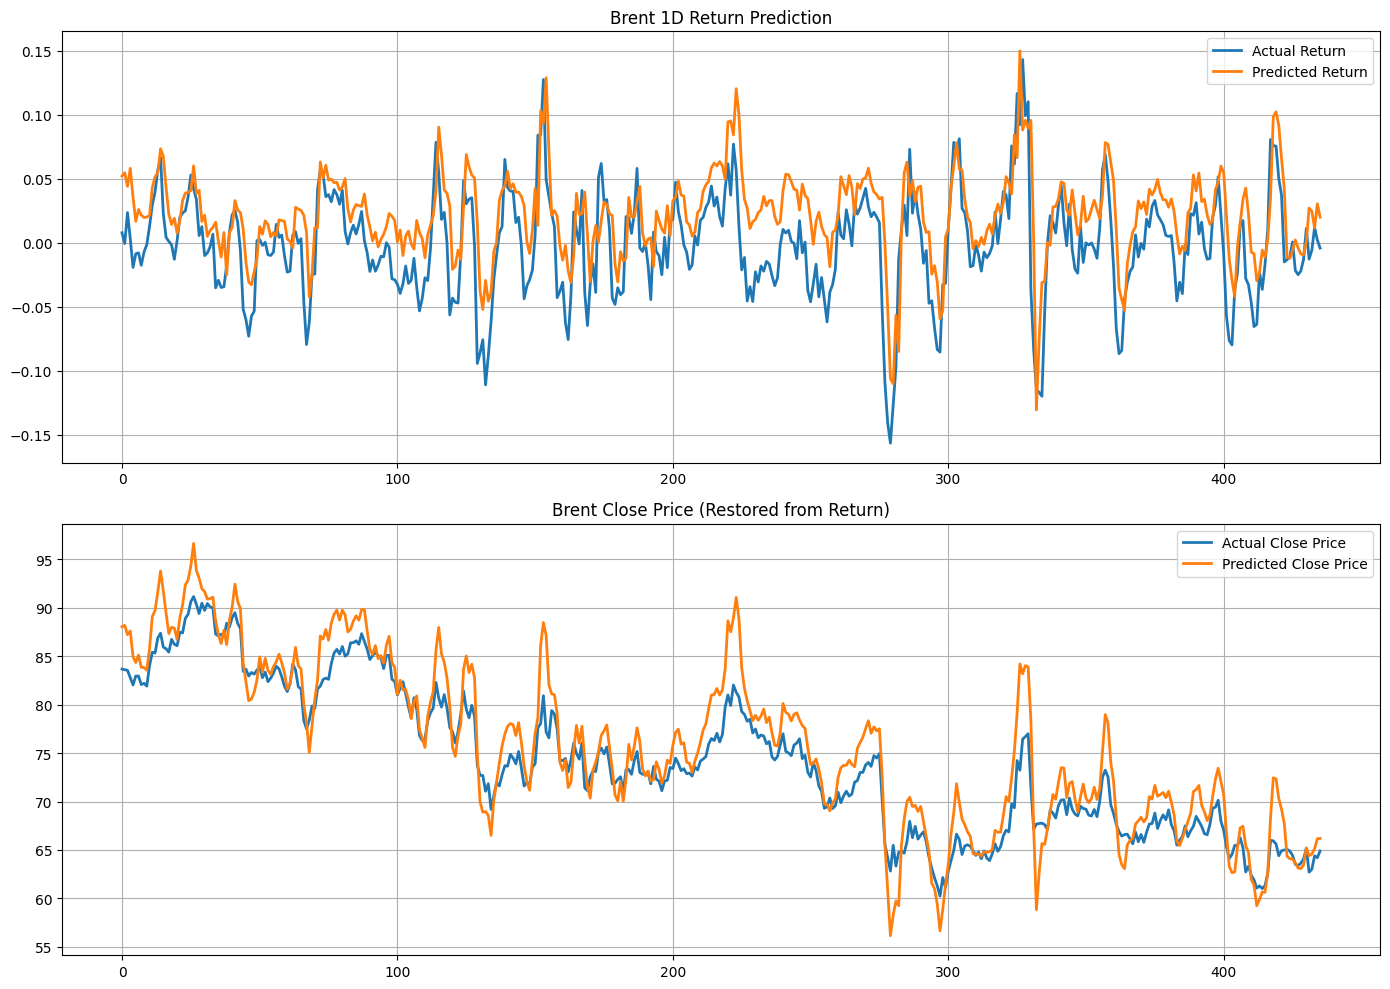

{'model': BiGRU(
   (gru): GRU(25, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.03612084557962081),
  'mae': 0.029269321197445325,
  'direction_accuracy': np.float64(0.6376146788990825)},
 'prediction': {'y_test': array([ 7.82851422e-03, -5.97531056e-04,  2.36461681e-02,  3.27158944e-03,
         -1.92468689e-02, -8.60422106e-03, -7.89289214e-03, -1.75942689e-02,
         -7.12565152e-03, -1.46273458e-03,  1.28977785e-02,  2.96528340e-02,
          3.97172811e-02,  5.69273854e-02,  6.66503809e-02,  2.28489610e-02,
          4.21447691e-03,  1.05465164e-03, -1.61122558e-03, -1.29319900e-02,
          1.62884694e-03,  1.98181931e-02,  2.32938998e-02,  2.50143881e-02,
          3.59420113e-02,  5.29678869e-02,  4.21810090e-02,  3.38595189e-02,
          5.62303205e-03,  1.26469491e-02, -1.00386503e-02, -7.89734820e-03,
         -3.09801713e-03,  6.70989137e-03, -3.52564359e-02, -2.93068567e-02,


In [43]:
# 1) RAW 다운로드
df_all = fetch_cot_raw()

# 2) 파생변수 추출
cot_daily = extract_cot_features(df_all)

# 3) 기존 features에 merge
features_with_cot = add_cot_to_features(features_b_1, cot_daily)

# 4) GRU 실행
result = run_bigru_pipeline(features_with_cot)
result


# D. A + EIA + COT

C:\Users\SKAX\AppData\Local\Temp\ipykernel_25512\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,131,132,147,148,149,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,188) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(name), header=None)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_25512\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105

[Epoch 01] train=0.20465, val=0.01827
[Epoch 02] train=0.09029, val=0.01798
[Epoch 03] train=0.08395, val=0.01880
[Epoch 04] train=0.07953, val=0.03006
[Epoch 05] train=0.09155, val=0.04062
[Epoch 06] train=0.07652, val=0.01824
[Epoch 07] train=0.07299, val=0.03106
[Epoch 08] train=0.06854, val=0.02496
[Epoch 09] train=0.06350, val=0.04150
[Epoch 10] train=0.05925, val=0.02938
[Epoch 11] train=0.06083, val=0.02697
[Epoch 12] train=0.06121, val=0.02836
[Epoch 13] train=0.06101, val=0.02440
[Epoch 14] train=0.06671, val=0.02868
[Epoch 15] train=0.06624, val=0.02833
[Epoch 16] train=0.05962, val=0.03156
[Epoch 17] train=0.05414, val=0.03665
[Epoch 18] train=0.05388, val=0.03362
[Epoch 19] train=0.05538, val=0.03388
[Epoch 20] train=0.05866, val=0.04003
[Epoch 21] train=0.05520, val=0.02541
[Epoch 22] train=0.05769, val=0.02625
[Epoch 23] train=0.05138, val=0.03169
[Epoch 24] train=0.05195, val=0.03882
[Epoch 25] train=0.04991, val=0.03938
[Epoch 26] train=0.05120, val=0.02403
[Epoch 27] t

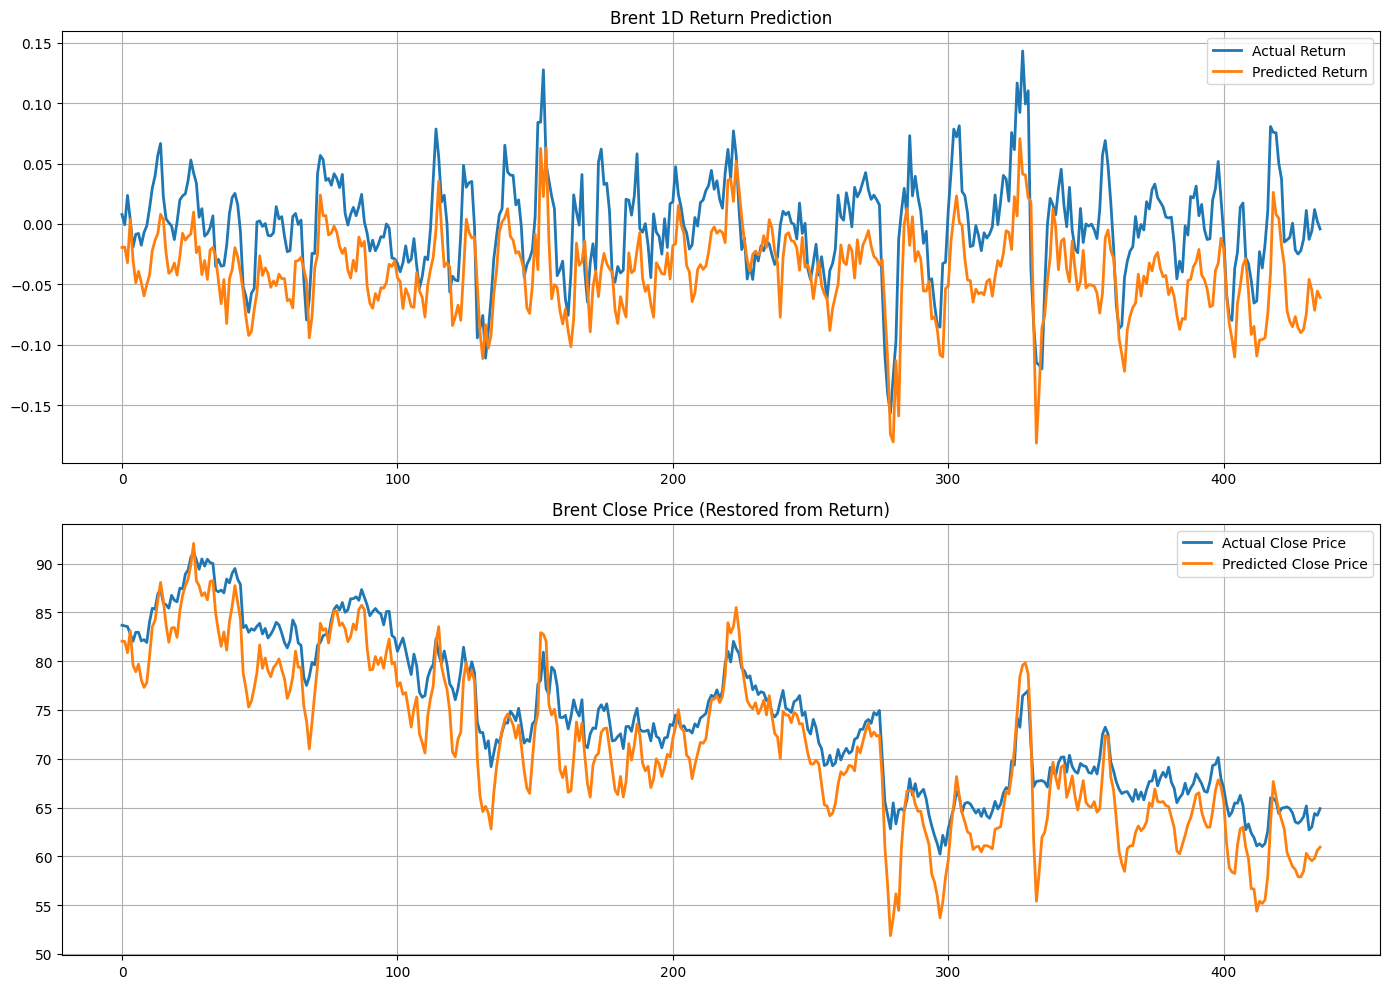

{'model': BiGRU(
   (gru): GRU(31, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.04765528357145369),
  'mae': 0.04098130486036774,
  'direction_accuracy': np.float64(0.591743119266055)},
 'prediction': {'y_test': array([ 7.82851422e-03, -5.97531056e-04,  2.36461681e-02,  3.27158944e-03,
         -1.92468689e-02, -8.60422106e-03, -7.89289214e-03, -1.75942689e-02,
         -7.12565152e-03, -1.46273458e-03,  1.28977785e-02,  2.96528340e-02,
          3.97172811e-02,  5.69273854e-02,  6.66503809e-02,  2.28489610e-02,
          4.21447691e-03,  1.05465164e-03, -1.61122558e-03, -1.29319900e-02,
          1.62884694e-03,  1.98181931e-02,  2.32938998e-02,  2.50143881e-02,
          3.59420113e-02,  5.29678869e-02,  4.21810090e-02,  3.38595189e-02,
          5.62303205e-03,  1.26469491e-02, -1.00386503e-02, -7.89734820e-03,
         -3.09801713e-03,  6.70989137e-03, -3.52564359e-02, -2.93068567e-02,
  

In [44]:
# 1) EIA 붙인 features_b
df_eia = features_b.copy()

# 2) COT raw 다운로드
df_all = fetch_cot_raw()

# 3) COT 파생변수 생성
cot_daily = extract_cot_features(df_all)

# 4) EIA + COT merge
df_final = add_cot_to_features(df_eia, cot_daily)

# 5) GRU 학습
result = run_bigru_pipeline(df_final)
result


# E. A + 뉴스 sentiment

In [45]:
def prepare_news_df(news_list):
    """
    news_list: JSON 데이터 리스트
    반환: date, sentiment만 정리된 DataFrame
    """
    rows = []
    for item in news_list:
        date = item.get("date_only") or item.get("date")  # date_only 우선 사용
        sent = None

        # sentiment 구조: { "score": -0.8, "explanation": "..."}
        if "sentiment" in item and isinstance(item["sentiment"], dict):
            sent = item["sentiment"].get("score", None)

        if date is not None and sent is not None:
            rows.append({"date": date, "sentiment": sent})

    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])
    return df

def aggregate_daily_sentiment(news_df):
    """
    date, sentiment 컬럼 가진 df → 일별 뉴스 피처 생성
    """
    daily = news_df.groupby("date").agg(
        news_sentiment_mean = ("sentiment", "mean"),
        news_sentiment_sum = ("sentiment", "sum"),
        news_sentiment_abs_sum = ("sentiment", lambda x: x.abs().sum()),
        news_count = ("sentiment", "count")
    )
    return daily

def merge_news_features(features_df, news_daily_df):
    """
    features_df : 브렌트/WTI/EIA/COT 등 포함한 기존 DF
    news_daily_df: aggregate_daily_sentiment 결과 DF
    """
    merged = features_df.merge(
        news_daily_df,
        left_index=True, 
        right_index=True,
        how="left"
    )

    # 뉴스 없는 날은 0으로 채우기
    merged = merged.fillna({
        "news_sentiment_mean": 0,
        "news_sentiment_sum": 0,
        "news_sentiment_abs_sum": 0,
        "news_count": 0
    })

    return merged


[Epoch 01] train=0.36946, val=0.01906
[Epoch 02] train=0.07789, val=0.02556
[Epoch 03] train=0.07461, val=0.02000
[Epoch 04] train=0.06953, val=0.01807
[Epoch 05] train=0.06954, val=0.01782
[Epoch 06] train=0.07238, val=0.01734
[Epoch 07] train=0.07057, val=0.01822
[Epoch 08] train=0.07342, val=0.01765
[Epoch 09] train=0.06814, val=0.01842
[Epoch 10] train=0.06338, val=0.01855
[Epoch 11] train=0.06072, val=0.01809
[Epoch 12] train=0.06526, val=0.01956
[Epoch 13] train=0.06639, val=0.02057
[Epoch 14] train=0.06825, val=0.01735
[Epoch 15] train=0.06077, val=0.01764
[Epoch 16] train=0.06392, val=0.01682
[Epoch 17] train=0.06046, val=0.01729
[Epoch 18] train=0.06034, val=0.02087
[Epoch 19] train=0.06154, val=0.01762
[Epoch 20] train=0.05835, val=0.02615
[Epoch 21] train=0.06147, val=0.02203
[Epoch 22] train=0.05566, val=0.01688
[Epoch 23] train=0.05357, val=0.01910
[Epoch 24] train=0.05406, val=0.01754
[Epoch 25] train=0.06094, val=0.03280
[Epoch 26] train=0.05917, val=0.01804
[Epoch 27] t

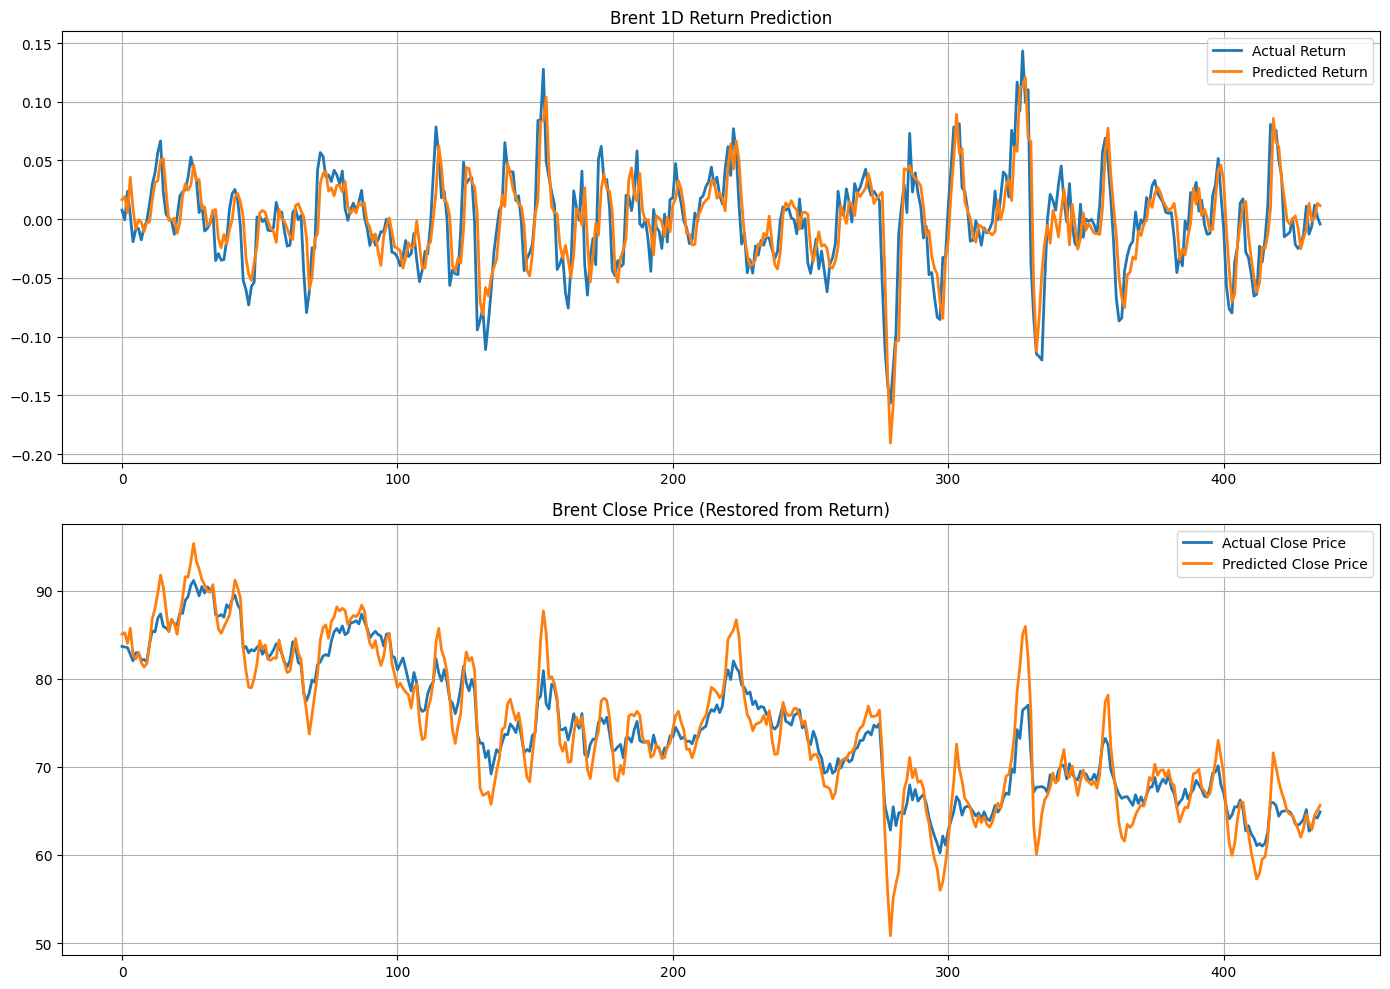

{'model': BiGRU(
   (gru): GRU(15, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.024762760993539478),
  'mae': 0.018335184388722066,
  'direction_accuracy': np.float64(0.7798165137614679)},
 'prediction': {'y_test': array([ 7.82851422e-03, -5.97531056e-04,  2.36461681e-02,  3.27158944e-03,
         -1.92468689e-02, -8.60422106e-03, -7.89289214e-03, -1.75942689e-02,
         -7.12565152e-03, -1.46273458e-03,  1.28977785e-02,  2.96528340e-02,
          3.97172811e-02,  5.69273854e-02,  6.66503809e-02,  2.28489610e-02,
          4.21447691e-03,  1.05465164e-03, -1.61122558e-03, -1.29319900e-02,
          1.62884694e-03,  1.98181931e-02,  2.32938998e-02,  2.50143881e-02,
          3.59420113e-02,  5.29678869e-02,  4.21810090e-02,  3.38595189e-02,
          5.62303205e-03,  1.26469491e-02, -1.00386503e-02, -7.89734820e-03,
         -3.09801713e-03,  6.70989137e-03, -3.52564359e-02, -2.93068567e-02,

In [46]:
with open('../data/embedded.json', 'r', encoding='utf-8') as f:
    news = json.load(f)

# 2) sentiment + date_only 추출
news_df = prepare_news_df(news)

# 3) 일별 집계 생성
news_daily = aggregate_daily_sentiment(news_df)

# 4) 기존 features(A/B/C/D)에 merge
features_E = merge_news_features(features, news_daily)

# 5) GRU 실험
result = run_bigru_pipeline(features_E)
result

# F. A + EIA + 뉴스 sentiment
# G. A + COT + 뉴스 sentiment
# H. A + EIA + COT + 뉴스 sentiment

In [47]:
# =========================================
# 1) Base 컬럼 정의
# =========================================
BASE_COLS = None  # run_bigru_pipeline 돌릴 때 자동 설정되므로 None으로 초기화


# =========================================
# 2) 중복 컬럼 자동 제거 후 join하는 안전 함수
# =========================================
def join_safe(left, right):
    # index 정렬 (안전성)
    left = left.sort_index()
    right = right.sort_index()

    # 중복 컬럼 자동 제거
    overlap = [c for c in right.columns if c in left.columns]
    if overlap:
        right = right.drop(columns=overlap)

    return left.join(right, how="left")


# =========================================
# 3) Feature Set 생성 함수 (A, A+EIA, A+COT, A+EIA+COT+NEWS)
# =========================================
def make_feature_sets(base_A, features_eia, features_cot, features_news):
    A = base_A.sort_index()
    eia = features_eia.sort_index()
    cot = features_cot.sort_index()
    news = features_news.sort_index()

    # ---- F: A + EIA + NEWS ----
    F = join_safe(A, eia)
    F = join_safe(F, news)

    # ---- G: A + COT + NEWS ----
    G = join_safe(A, cot)
    G = join_safe(G, news)

    # ---- H: A + EIA + COT + NEWS ----
    H = join_safe(A, eia)
    H = join_safe(H, cot)
    H = join_safe(H, news)

    return {"F": F, "G": G, "H": H}



===== Running F =====
[Epoch 01] train=0.18501, val=0.05969
[Epoch 02] train=0.09569, val=0.05291
[Epoch 03] train=0.08957, val=0.02859
[Epoch 04] train=0.08589, val=0.02219
[Epoch 05] train=0.07915, val=0.03238
[Epoch 06] train=0.07548, val=0.03877
[Epoch 07] train=0.06899, val=0.02715
[Epoch 08] train=0.07377, val=0.02804
[Epoch 09] train=0.06698, val=0.02919
[Epoch 10] train=0.06667, val=0.02661
[Epoch 11] train=0.06392, val=0.02464
[Epoch 12] train=0.06277, val=0.03078
[Epoch 13] train=0.06236, val=0.02745
[Epoch 14] train=0.05817, val=0.02583
[Epoch 15] train=0.05823, val=0.02883
[Epoch 16] train=0.05569, val=0.02214
[Epoch 17] train=0.05380, val=0.02487
[Epoch 18] train=0.05693, val=0.03289
[Epoch 19] train=0.05651, val=0.03012
[Epoch 20] train=0.05493, val=0.02301
[Epoch 21] train=0.04745, val=0.02235
[Epoch 22] train=0.05269, val=0.02491
[Epoch 23] train=0.04767, val=0.02764
[Epoch 24] train=0.05010, val=0.02203
[Epoch 25] train=0.04734, val=0.02905
[Epoch 26] train=0.04638, v

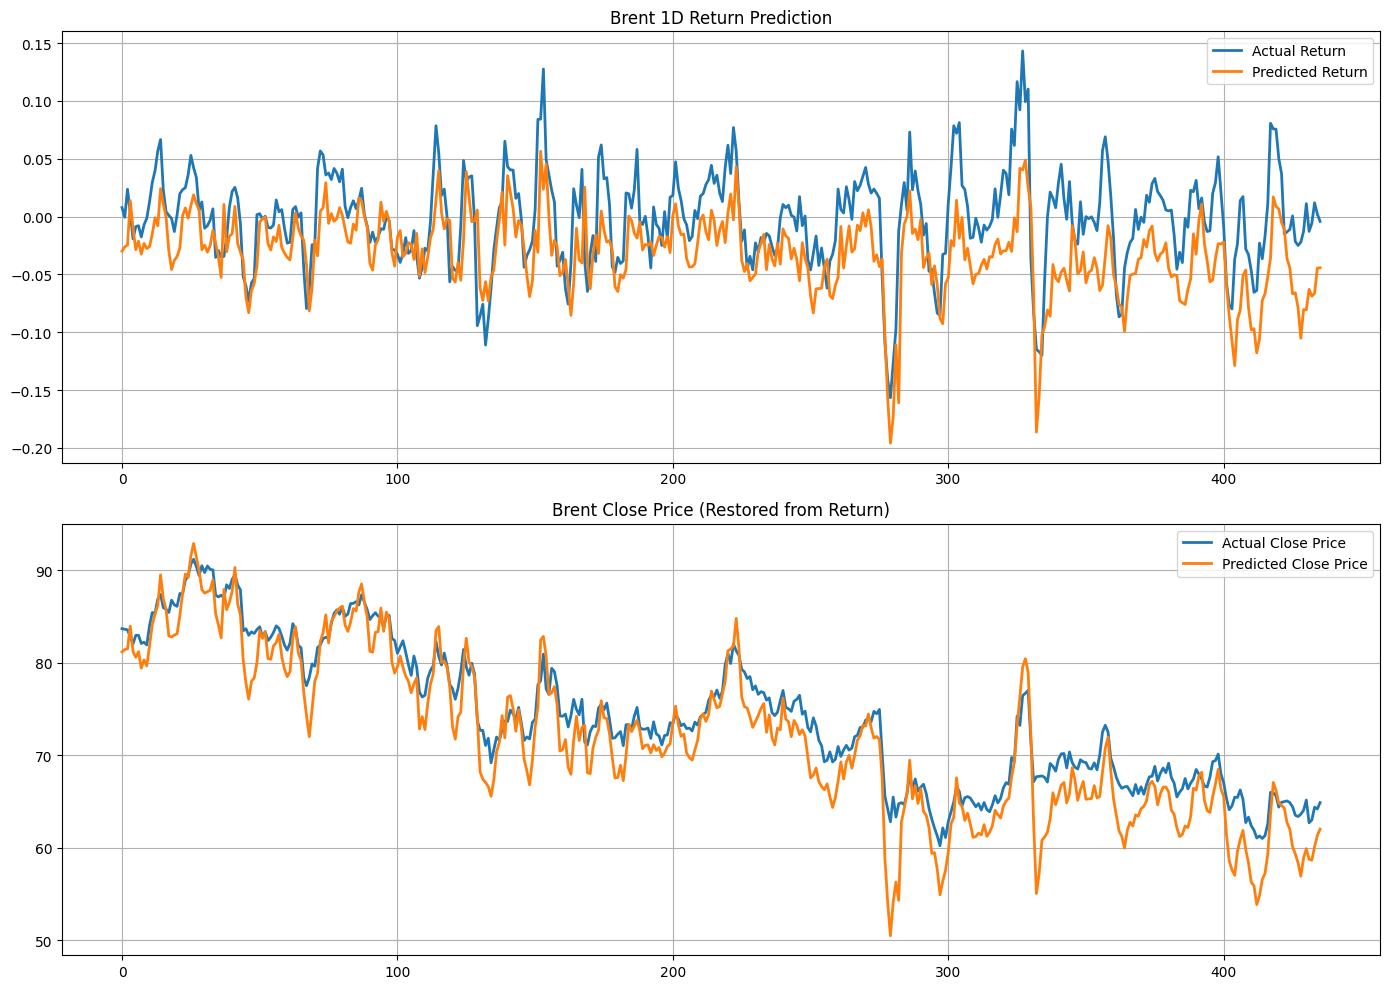


===== Running G =====
[Epoch 01] train=0.25721, val=0.06168
[Epoch 02] train=0.09555, val=0.07689
[Epoch 03] train=0.09210, val=0.04014
[Epoch 04] train=0.07408, val=0.03803
[Epoch 05] train=0.07045, val=0.02883
[Epoch 06] train=0.06649, val=0.02420
[Epoch 07] train=0.07137, val=0.02804
[Epoch 08] train=0.06921, val=0.04904
[Epoch 09] train=0.06582, val=0.02770
[Epoch 10] train=0.06932, val=0.02513
[Epoch 11] train=0.06195, val=0.01958
[Epoch 12] train=0.05524, val=0.02089
[Epoch 13] train=0.05522, val=0.03435
[Epoch 14] train=0.06185, val=0.04932
[Epoch 15] train=0.05730, val=0.02677
[Epoch 16] train=0.05518, val=0.02145
[Epoch 17] train=0.05422, val=0.02520
[Epoch 18] train=0.04942, val=0.01927
[Epoch 19] train=0.04805, val=0.02163
[Epoch 20] train=0.04802, val=0.02030
[Epoch 21] train=0.05409, val=0.02403
[Epoch 22] train=0.04757, val=0.02241
[Epoch 23] train=0.04655, val=0.02399
[Epoch 24] train=0.04198, val=0.02279
[Epoch 25] train=0.04183, val=0.02279
[Epoch 26] train=0.04623, v

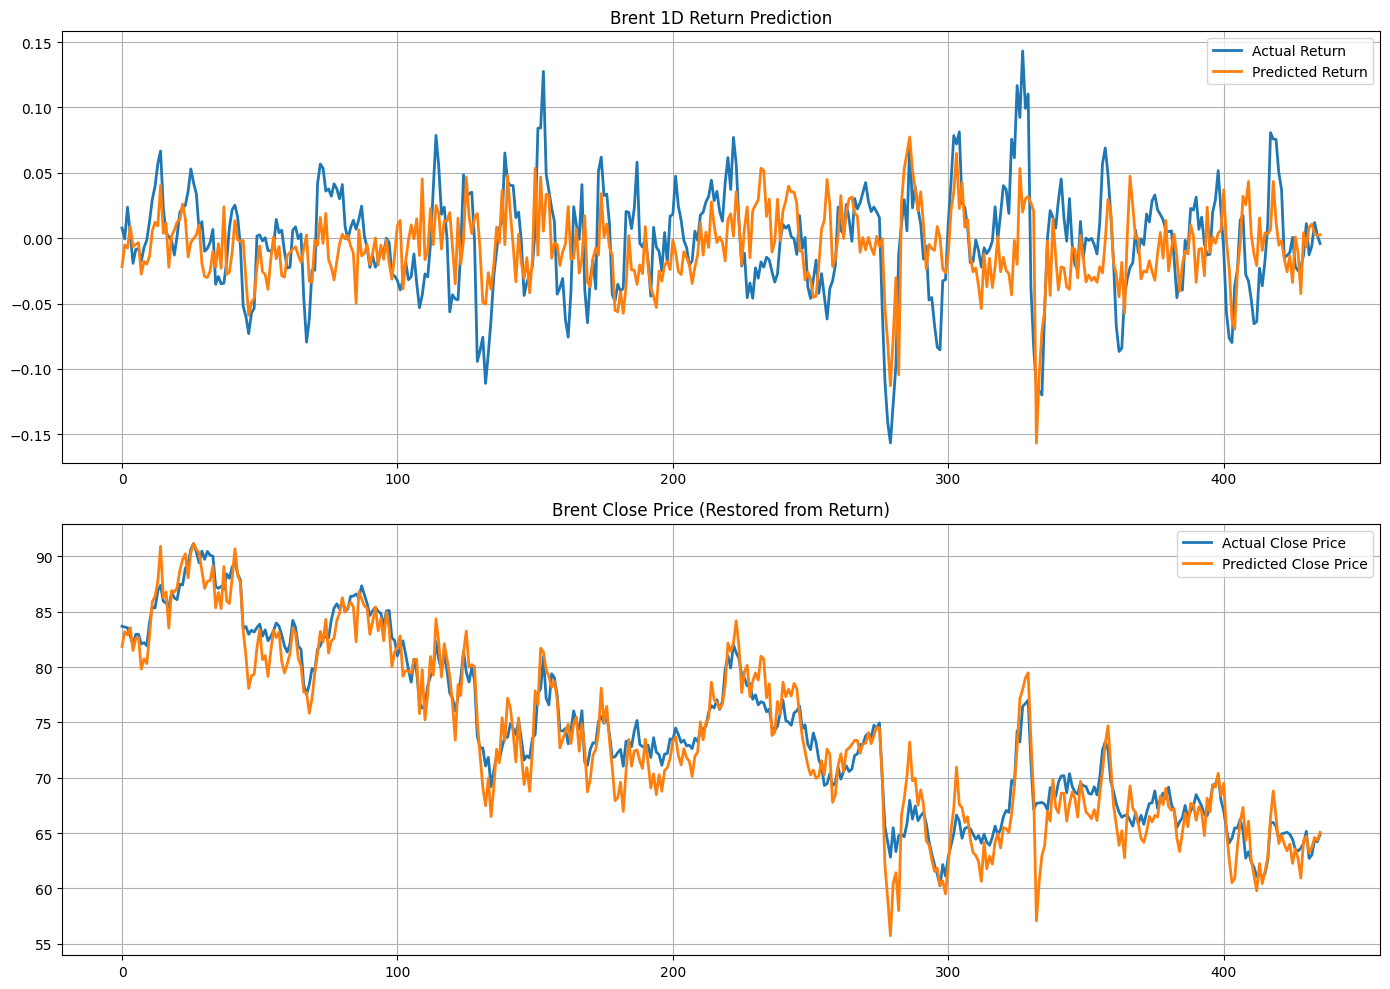


===== Running H =====
[Epoch 01] train=0.52379, val=0.09443
[Epoch 02] train=0.09260, val=0.06728
[Epoch 03] train=0.08658, val=0.05202
[Epoch 04] train=0.08192, val=0.05499
[Epoch 05] train=0.07579, val=0.04222
[Epoch 06] train=0.07980, val=0.03206
[Epoch 07] train=0.07728, val=0.03074
[Epoch 08] train=0.07398, val=0.04349
[Epoch 09] train=0.06786, val=0.03472
[Epoch 10] train=0.06083, val=0.03888
[Epoch 11] train=0.06145, val=0.03886
[Epoch 12] train=0.05861, val=0.04999
[Epoch 13] train=0.05636, val=0.04364
[Epoch 14] train=0.05593, val=0.03913
[Epoch 15] train=0.05845, val=0.03739
[Epoch 16] train=0.05429, val=0.04509
[Epoch 17] train=0.05191, val=0.03668
[Epoch 18] train=0.05387, val=0.05392
[Epoch 19] train=0.05269, val=0.03541
[Epoch 20] train=0.05493, val=0.04034
[Epoch 21] train=0.05001, val=0.04888
[Epoch 22] train=0.04668, val=0.04527
[Epoch 23] train=0.05012, val=0.04262
[Epoch 24] train=0.04874, val=0.04684
[Epoch 25] train=0.04988, val=0.03601
[Epoch 26] train=0.04622, v

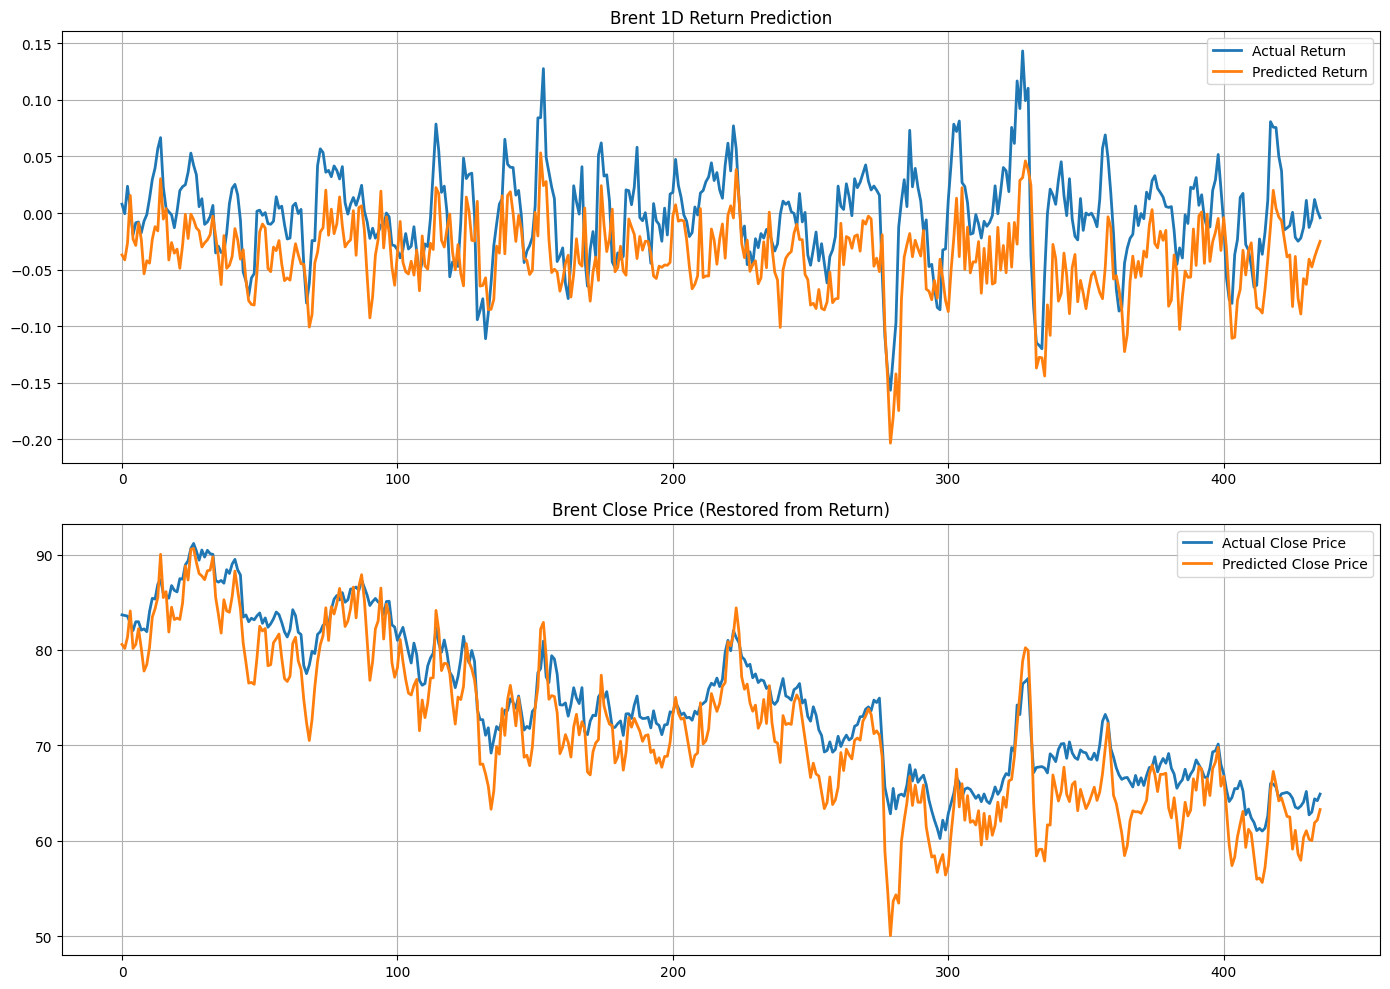

In [48]:
feature_sets = make_feature_sets(
    base_A = features,          # A: Brent+WTI 기본
    features_eia = features_b,  # B: A+EIA
    features_cot = df_final,    # D: A+EIA+COT
    features_news = features_E  # E: A+NEWS
)

for name, df in feature_sets.items():
    print(f"\n===== Running {name} =====")
    df = df.dropna()
    result = run_bigru_pipeline(df)
    result


# 클러스터링 기반

In [49]:
def prepare_timeseries_df(df):
    """
    CSV로부터 읽은 raw DF에서
    Date → datetime 변환 + index 설정 + 소트 + 중복 제거까지 처리
    """
    df = df.copy()

    # 1) Date 컬럼 이름이 'Date' 또는 'date' 뭐든 자동 처리
    date_col = None
    for c in df.columns:
        if c.lower() == "date":
            date_col = c
            break

    if date_col is None:
        raise KeyError("Date 컬럼을 찾지 못했습니다. 'Date' 또는 'date' 이름이어야 합니다.")

    # 2) 날짜 변환
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    # 3) 날짜가 NaT인 행 제거
    df = df.dropna(subset=[date_col])

    # 4) index 설정
    df = df.set_index(date_col)

    # 5) 타임소트
    df = df.sort_index()

    # 6) index 중복 제거
    df = df[~df.index.duplicated(keep="last")]

    return df

clust=pd.read_csv('checkpoint_1117_with_cluster30_graph_brent_ridge_impact.csv')
df_ts = prepare_timeseries_df(clust)

print(df_ts.head())


            brent_close  wti_close  brent_wti_spread  brent_ret_1d  \
Date                                                                 
2014-01-02   107.779999  95.440002         12.339996     -0.027256   
2014-01-03   106.889999  93.959999         12.930000     -0.008258   
2014-01-06   106.730003  93.430000         13.300003     -0.001497   
2014-01-07   107.349998  93.669998         13.680000      0.005809   
2014-01-08   107.150002  92.330002         14.820000     -0.001863   

            brent_ret_5d  brent_ret_20d  brent_ma_5  brent_ma_20  brent_ma_60  \
Date                                                                            
2014-01-02     -0.036819      -0.032930  110.790001     110.6705   109.391334   
2014-01-03     -0.045455      -0.050879  109.772000     110.3840   109.356167   
2014-01-06     -0.048583      -0.046031  108.682001     110.1265   109.310667   
2014-01-07     -0.034709      -0.032709  107.910001     109.9450   109.271834   
2014-01-08     -0.03294

In [50]:
def attach_cluster_to_A(base_A, features_cluster):
    """
    base_A : 기존 A (Brent + WTI 기본 피처셋)
    features_cluster : cluster, impact 값이 모두 들어있는 DF
    """

    # 필요 컬럼만 추출
    cluster_cols = [
        "cluster_0","cluster_1","cluster_2","cluster_3","cluster_4",
        "cluster_5","cluster_6","cluster_7","cluster_8",
        "news_impact_brent_day0_value","news_impact_brent_day1_value",
        "news_impact_brent_day2_value","news_impact_brent_day3_value",
        "news_impact_brent_day4_value","news_impact_brent_total"
    ]

    cluster_df = features_cluster[cluster_cols].copy()

    # index(Date) 기준 merge
    A_with_cluster = base_A.join(cluster_df, how="left")

    return A_with_cluster


In [ ]:
def attach_cluster_to_H(H, features_cluster):
    """
    H : A + EIA + COT + NEWS 풀 피처셋
    features_cluster : cluster + 영향을 포함한 DF
    """

    cluster_cols = [
        "cluster_0","cluster_1","cluster_2","cluster_3","cluster_4",
        "cluster_5","cluster_6","cluster_7","cluster_8",
        "news_impact_brent_day0_value","news_impact_brent_day1_value",
        "news_impact_brent_day2_value","news_impact_brent_day3_value",
        "news_impact_brent_day4_value","news_impact_brent_total"
    ]

    cluster_df = features_cluster[cluster_cols].copy()

    H_with_cluster = H.join(cluster_df, how="left")

    return H_with_cluster

In [53]:
H=df_ts.get('K')

In [54]:
# A + Cluster
A_with_cluster = attach_cluster_to_A(features, df_ts)

# H + Cluster
H_with_cluster = attach_cluster_to_H(H, df_ts)

# GRU 학습
result = run_bigru_pipeline(H_with_cluster.dropna())
result

AttributeError: 'NoneType' object has no attribute 'join'

[Epoch 01] train=0.20411, val=0.02590
[Epoch 02] train=0.09818, val=0.02380
[Epoch 03] train=0.08088, val=0.02250
[Epoch 04] train=0.07865, val=0.02262
[Epoch 05] train=0.07258, val=0.03419
[Epoch 06] train=0.06749, val=0.02023
[Epoch 07] train=0.05986, val=0.02070
[Epoch 08] train=0.05963, val=0.02012
[Epoch 09] train=0.05800, val=0.01998
[Epoch 10] train=0.06203, val=0.01929
[Epoch 11] train=0.06456, val=0.02310
[Epoch 12] train=0.05826, val=0.02041
[Epoch 13] train=0.05369, val=0.02078
[Epoch 14] train=0.05483, val=0.02110
[Epoch 15] train=0.05098, val=0.01988
[Epoch 16] train=0.05235, val=0.02205
[Epoch 17] train=0.05640, val=0.02730
[Epoch 18] train=0.04576, val=0.01981
[Epoch 19] train=0.04792, val=0.02565
[Epoch 20] train=0.05285, val=0.02124
[Epoch 21] train=0.04712, val=0.02125
[Epoch 22] train=0.04464, val=0.01897
[Epoch 23] train=0.04447, val=0.02107
[Epoch 24] train=0.04397, val=0.02475
[Epoch 25] train=0.04084, val=0.02137
[Epoch 26] train=0.04106, val=0.02198
[Epoch 27] t

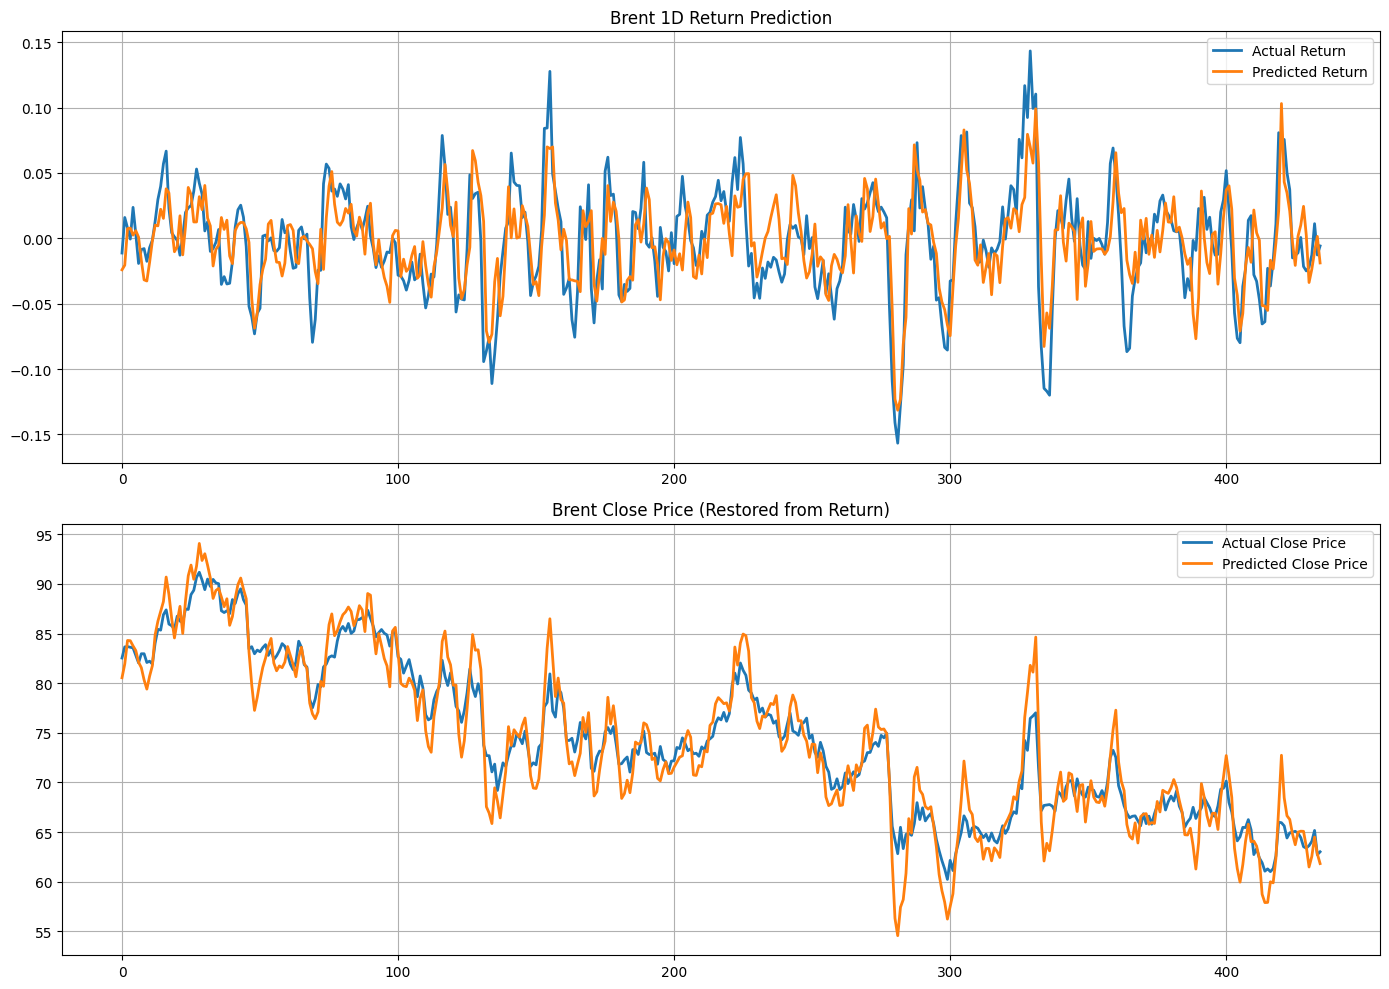

{'model': BiGRU(
   (gru): GRU(26, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.029360054031756826),
  'mae': 0.022696581615163566,
  'direction_accuracy': np.float64(0.7310344827586207)},
 'prediction': {'y_test': array([-1.12615602e-02,  1.59097067e-02,  7.82851422e-03, -5.97531056e-04,
          2.36461681e-02,  3.27158944e-03, -1.92468689e-02, -8.60422106e-03,
         -7.89289214e-03, -1.75942689e-02, -7.12565152e-03, -1.46273458e-03,
          1.28977785e-02,  2.96528340e-02,  3.97172811e-02,  5.69273854e-02,
          6.66503809e-02,  2.28489610e-02,  4.21447691e-03,  1.05465164e-03,
         -1.61122558e-03, -1.29319900e-02,  1.62884694e-03,  1.98181931e-02,
          2.32938998e-02,  2.50143881e-02,  3.59420113e-02,  5.29678869e-02,
          4.21810090e-02,  3.38595189e-02,  5.62303205e-03,  1.26469491e-02,
         -1.00386503e-02, -7.89734820e-03, -3.09801713e-03,  6.70989137e-03,

In [55]:
result = run_bigru_pipeline(A_with_cluster.dropna())
result